## Preambule

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd
import xarray as xr
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

import ixmp4

%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import os
os.chdir(pathlib.Path("K:/Code/iam-fingerprints").resolve())
from src.globals import settings, paths

In [15]:
font = 'Frutiger Lt Pro'
font_path = 'K:/Data/Fonts/'+font+'/'
font_files = [f for f in os.listdir(font_path) if os.path.isfile(os.path.join(font_path, f))]
for file in font_files:
    font_prop = fm.FontProperties(fname=font_path+file)
    fm.fontManager.addfont(font_path+file)
plt.rcParams['font.family'] = font_prop.get_name()

## Read data

In [16]:
scenarios_to_analyze = ['C400-lin',
                        'C80-gr5',
                        'C160-gr5',
                        'C0to400-lin',
                        'C400-lin-LimBio',
                        'C400-lin-LimCCS']

In [17]:
variable_list = ['Emissions|Kyoto Gases',
                 'Emissions|CO2',
                 'Emissions|CO2|Energy and Industrial Processes',
                 'Emissions|CH4',
                 
                 'Primary Energy',
                 'Primary Energy|Coal',
                 'Primary Energy|Oil',
                 'Primary Energy|Gas',
                 'Primary Energy|Biomass',
                 'Primary Energy|Solar',
                 'Primary Energy|Wind',
                 'Primary Energy|Fossil',
                 'Primary Energy|Nuclear',
                 
                 'Final Energy',
                 'Final Energy|Industry',
                 'Final Energy|Transportation',
                 'Final Energy|Residential and Commercial',
                 
                 'GDP|PPP']	

In [39]:
colors = [
    "#4477AA",  # Blue
    "#EE6677",  # Red
    "#228833",  # Green
    "#CCBB44",  # Yellow
    "#66CCEE",  # Cyan
    "#AA3377",  # Purple
    "#EE7733",  # Orange
    "#BBBBBB",  # Grey
    "#000000",  # Black
    "#8B4513",  # Brown
]

In [19]:
platform = ixmp4.Platform("iam-diagnostics-internal")
df_download = platform.iamc.tabulate(variable=variable_list,
                                     region='World')

[INFO] 09:19:57 - ixmp4.data.backend.api: Connected to IXMP4 Platform 'iam-diagnostics-internal'
[WARNING] 09:19:57 - ixmp4.data.backend.api: IXMP4 Client and Server versions do not match. (Client: 0.10.0, Server: 0.16.4)
[INFO] 09:19:57 - ixmp4.data.backend.api: Platform notice: >
This app is for the IAM Diagnostic exercise. It follows the access strategy of IPCC reports and the Scenario Compass Sandbox where modeling teams only see their own scenario submissions, but not scenarios submitted by other teams. Only the group "IAM Diagnostics (2026) Authors" can see all scenarios.


In [20]:
ds = (df_download.set_index(["model","scenario","region","variable","year",])["value"].to_xarray().to_dataset(name="value"))
ds = ds.interpolate_na(dim="year", method="linear")
ds_ex = ds.ffill("year").bfill("year")

## Add indicators

In [21]:
# Dimension 1
ds["Relative Abatement Index"] = ds.sel(variable = 'Emissions|Kyoto Gases').value / ds.sel(variable = 'Emissions|Kyoto Gases', scenario='Current-Policies').value

# Dimension 2
ds["Carbon Intensity"] = ds.sel(variable = 'Emissions|Kyoto Gases').value / ds.sel(variable = 'Final Energy').value
ds["Carbon Intensity Reduction"] = (ds.sel(year=2020)['Carbon Intensity'] - ds['Carbon Intensity']) / ds.sel(year=2020)['Carbon Intensity']
ds["Energy Intensity"] = ds.sel(variable = 'Final Energy').value / ds.sel(variable = 'GDP|PPP').value
ds["Energy Intensity Reduction"] = (ds.sel(year=2020)['Energy Intensity'] - ds['Energy Intensity']) / ds.sel(year=2020)['Energy Intensity']

# Dimension 3
ds["Fraction Primary Coal"] = ds.sel(variable = 'Primary Energy|Coal').value / ds.sel(variable = 'Primary Energy').value
ds["Fraction Primary Fossil"] = ds.sel(variable = 'Primary Energy|Fossil').value / ds.sel(variable = 'Primary Energy').value
ds["Fraction Primary Gas"] = ds.sel(variable = 'Primary Energy|Gas').value / ds.sel(variable = 'Primary Energy').value

# Dimension 5
pes = ["Coal", "Oil", "Gas", "Solar", "Wind", "Nuclear", "Biomass"]
sumdif = None
for p in pes:
    fr_2020 = (
        ds.sel(variable="Primary Energy|" + p, year=2020).value /
        ds.sel(variable="Primary Energy", year=2020).value
    )
    fr_2050 = (
        ds.sel(variable="Primary Energy|" + p, year=2050).value /
        ds.sel(variable="Primary Energy", year=2050).value
    )
    diff = abs(fr_2050 - fr_2020)
    diff = diff.fillna(0)
    sumdif = diff if sumdif is None else sumdif + diff
ds['Transformation Index'] = sumdif

In [22]:
# Dimension 1
ds_ex["Relative Abatement Index"]       = ds_ex.sel(variable = 'Emissions|Kyoto Gases').value / ds_ex.sel(variable = 'Emissions|Kyoto Gases', scenario='Current-Policies').value

# Dimension 2
ds_ex["Carbon Intensity"]               = ds_ex.sel(variable = 'Emissions|Kyoto Gases').value / ds_ex.sel(variable = 'Final Energy').value
ds_ex["Carbon Intensity Reduction"]     = (ds_ex.sel(year=2020)['Carbon Intensity'] - ds_ex['Carbon Intensity']) / ds_ex.sel(year=2020)['Carbon Intensity']
ds_ex["Energy Intensity"]               = ds_ex.sel(variable = 'Final Energy').value / ds_ex.sel(variable = 'GDP|PPP').value
ds_ex["Energy Intensity Reduction"]     = (ds_ex.sel(year=2020)['Energy Intensity'] - ds_ex['Energy Intensity']) / ds_ex.sel(year=2020)['Energy Intensity']

# Dimension 3
ds_ex["Fraction Primary Coal"]          = ds_ex.sel(variable = 'Primary Energy|Coal').value / ds_ex.sel(variable = 'Primary Energy').value
ds_ex["Fraction Primary Fossil"]        = ds_ex.sel(variable = 'Primary Energy|Fossil').value / ds_ex.sel(variable = 'Primary Energy').value
ds_ex["Fraction Primary Gas"]           = ds_ex.sel(variable = 'Primary Energy|Gas').value / ds_ex.sel(variable = 'Primary Energy').value

# Dimension 5
pes = ["Coal", "Oil", "Gas", "Solar", "Wind", "Nuclear", "Biomass"]
sumdif = None
for p in pes:
    fr_2020 = (
        ds_ex.sel(variable="Primary Energy|" + p, year=2020).value /
        ds_ex.sel(variable="Primary Energy", year=2020).value
    )
    fr_2050 = (
        ds_ex.sel(variable="Primary Energy|" + p, year=2050).value /
        ds_ex.sel(variable="Primary Energy", year=2050).value
    )
    diff = abs(fr_2050 - fr_2020)
    diff = diff.fillna(0)
    sumdif = diff if sumdif is None else sumdif + diff
ds_ex['Transformation Index'] = sumdif

## Plots

(2010.0, 2100.0)

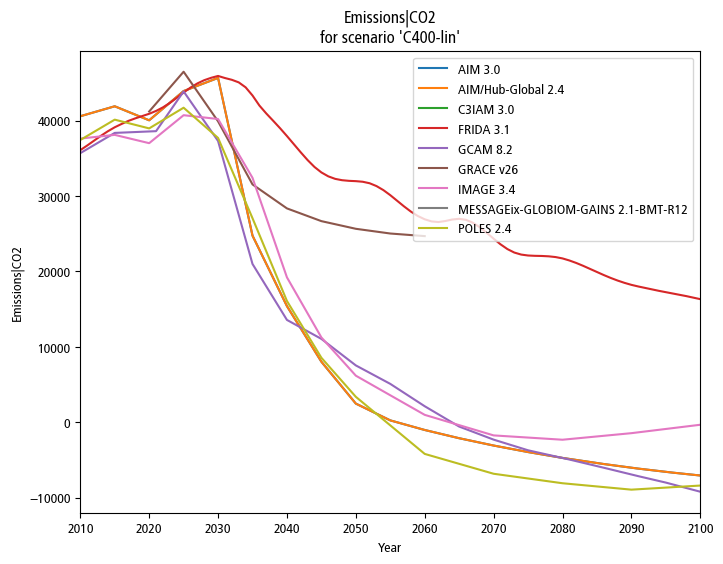

In [40]:
VAR = 'Emissions|CO2'
SCEN = 'C400-lin'

fig, ax = plt.subplots(figsize=(8, 6))
for mod_i, mod in enumerate(ds.model):
    plt.plot(ds.year, ds.sel(model=mod, scenario=SCEN, region='World', variable=VAR).value, label=mod.values)
plt.legend()
ax.set_title(f"{VAR}\nfor scenario '{SCEN}'")
ax.set_ylabel(f"{VAR}")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])

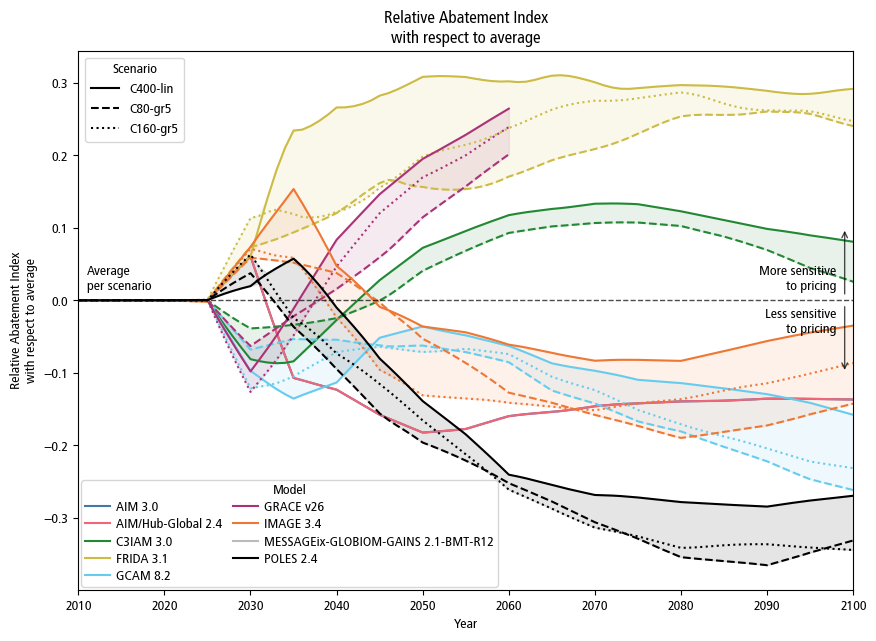

In [45]:
IND = 'Relative Abatement Index'

fig, ax = plt.subplots(figsize=(10, 7))
for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]
    ys = []
    short_name = f"{str(mod.values)[:]}"# {str(mod.values).split()[-1]}"
    for SCEN_i, SCEN in enumerate(scenarios_to_analyze[:3]):
        median = ds_ex.sel(scenario=SCEN, region='World')[IND].mean(dim='model')
        style = ['-', '--', ':', '-.', '-.', '-.'][SCEN_i]
        lab = [short_name, None, None, None, None, None][SCEN_i]
        plt.plot(ds.year,
                 ds.sel(model=mod, scenario=SCEN, region='World')[IND]-median,
                 c=color,
                 ls=style,
                 label=lab)
        ys.append(ds.sel(model=mod, scenario=SCEN, region='World')[IND]-median)
    # Fill between scenario lines
    ys = xr.concat(ys, dim='scenario')
    y0 = ys.min(dim='scenario')
    y1 = ys.max(dim='scenario')
    ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                    color=color, alpha=0.1)
legend1 = ax.legend(
    title="Model",
    loc="lower left",
    ncol=2,
    fontsize=10,
    title_fontsize=10,
    columnspacing=0.8,
    handletextpad=0.4,
    labelspacing=0.3,
    handlelength=1.8,
    borderpad=0.3,
    borderaxespad=0.2,
)
ax.add_artist(legend1)

# Add second legend on the line styles
scenario_handles = [
    Line2D([0], [0], color='black', linestyle='-',  label='C400-lin'),
    Line2D([0], [0], color='black', linestyle='--', label='C80-gr5'),
    Line2D([0], [0], color='black', linestyle=':',  label='C160-gr5'),
]
ax.legend(handles=scenario_handles, title="Scenario", loc="upper left")

# Add horizontal line at 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2011, 0.01, 'Average\nper scenario', color='black', fontsize=10, va='bottom', ha='left')
ax.text(2098, -0.01, 'Less sensitive\nto pricing', color='black', fontsize=10, va='top', ha='right')
ax.text(2098, 0.01, 'More sensitive\nto pricing', color='black', fontsize=10, va='bottom', ha='right')

# Small arrow from text upward and downward
ax.annotate('', xy=(2099, 0.005), xytext=(2099, 0.1),
            arrowprops=dict(arrowstyle='<-', color='black', linewidth=1, alpha=0.7))
ax.annotate('', xy=(2099, -0.005), xytext=(2099, -0.1),
            arrowprops=dict(arrowstyle='<-', color='black', linewidth=1, alpha=0.7))

ax.set_title(f"{IND}\nwith respect to average")
ax.set_ylabel(f"{IND}\nwith respect to average")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])
plt.savefig(paths.figures_Xdrive / "rai_time.png", dpi=500, bbox_inches='tight')

(2010.0, 2100.0)

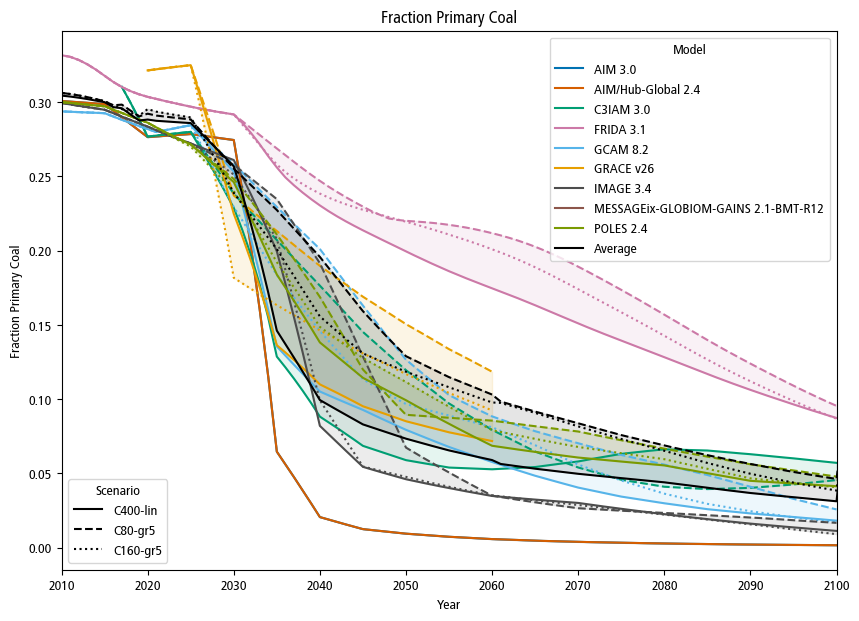

In [25]:
IND = 'Fraction Primary Coal'

fig, ax = plt.subplots(figsize=(10, 7))
for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]
    ys = []
    for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5']):
        style = ['-', '--', ':'][SCEN_i]
        lab = [mod.values, None, None][SCEN_i]
        plt.plot(ds.year,
                 ds.sel(model=mod, scenario=SCEN, region='World')[IND],
                 c=color,
                 ls=style,
                 label=lab)
        ys.append(ds.sel(model=mod, scenario=SCEN, region='World')[IND])
    # Fill between scenario lines
    ys = xr.concat(ys, dim='scenario')
    y0 = ys.min(dim='scenario')
    y1 = ys.max(dim='scenario')
    ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                    color=color, alpha=0.1)
# Add average
ys = []
for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5']):
    style = ['-', '--', ':'][SCEN_i]
    lab = ["Average", None, None][SCEN_i]
    plt.plot(ds.year,
                ds.sel(scenario=SCEN, region='World')[IND].mean(dim='model'),
                c='black',
                ls=style,
                label=lab)
    ys.append(ds.sel(scenario=SCEN, region='World')[IND].mean(dim='model'))
ys = xr.concat(ys, dim='scenario')
y0 = ys.min(dim='scenario')
y1 = ys.max(dim='scenario')
ax.fill_between(ds.year.values.astype(int),y0.values,y1.values,
                color='black', alpha=0.1)

legend1 = ax.legend(title="Model", loc="upper right")
ax.add_artist(legend1)

# Add second legend on the line styles
scenario_handles = [
    Line2D([0], [0], color='black', linestyle='-',  label='C400-lin'),
    Line2D([0], [0], color='black', linestyle='--', label='C80-gr5'),
    Line2D([0], [0], color='black', linestyle=':',  label='C160-gr5'),
]
ax.legend(handles=scenario_handles, title="Scenario", loc="lower left")

ax.set_title(f"{IND}")
ax.set_ylabel(f"{IND}")
ax.set_xlabel("Year")
ax.set_xlim([2010, 2100])

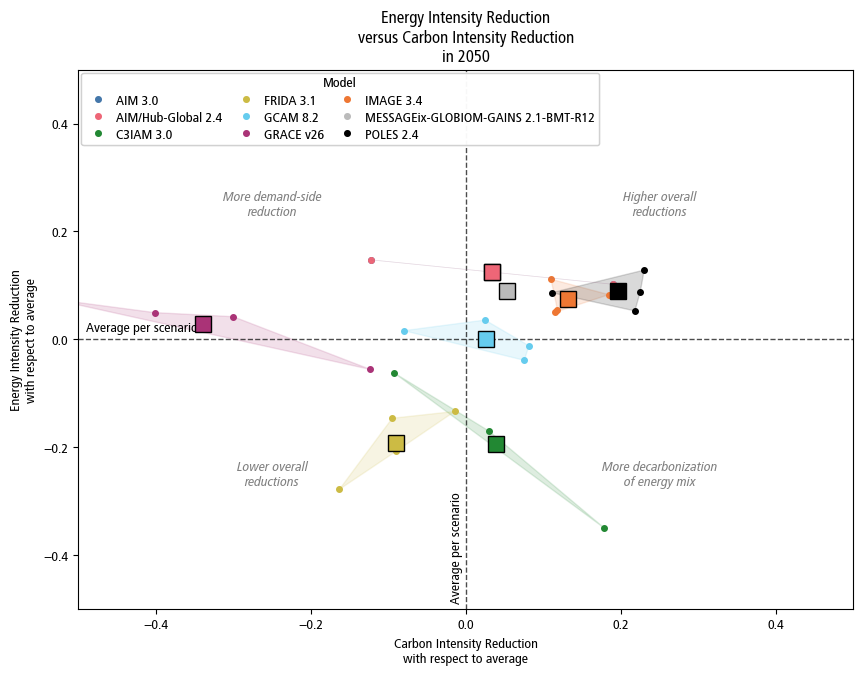

In [46]:
INDx = 'Carbon Intensity Reduction'
INDy = 'Energy Intensity Reduction'
fig, ax = plt.subplots(figsize=(10, 7))

for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]

    points = []

    short_name = f"{str(mod.values)[:]}"# {str(mod.values).split()[-1]}"

    for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5', 'Current-Policies']):

        median_x = ds_ex.sel(scenario=SCEN, region='World', year=2050)[INDx].mean(dim='model')
        median_y = ds_ex.sel(scenario=SCEN, region='World', year=2050)[INDy].mean(dim='model')

        x = float(ds.sel(model=mod, scenario=SCEN, region='World', year=2050)[INDx] - median_x)
        y = float(ds.sel(model=mod, scenario=SCEN, region='World', year=2050)[INDy] - median_y)

        points.append((x, y))

        ax.plot(
            x, y,
            '.',
            color=color,
            markersize=8,
            label=short_name if SCEN_i == 0 else None
        )

    points = np.array(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]

    # Plot average
    if len(points) > 0:
        avg = points.mean(axis=0)
        ax.plot(avg[0], avg[1],
                marker='s', markersize=12,
                color=color, markeredgecolor='k', zorder=5)
    if len(points) == 2:
        ax.plot(points[:,0],points[:,1],
                color=color, lw=0.5, alpha=0.15, zorder=4)
    # Only draw if at least 3 valid points remain
    if len(points) >= 3:
        centroid = points.mean(axis=0)
        angles = np.arctan2(points[:,1] - centroid[1],
                            points[:,0] - centroid[0])
        points = points[np.argsort(angles)]

        ax.add_patch(Polygon(points,
                            closed=True,
                            facecolor=color,
                            edgecolor=color,
                            alpha=0.15))

# Legend
legend1 = ax.legend(
    title="Model",
    loc="upper left",
    ncol=3,
    fontsize=10,
    title_fontsize=10,
    columnspacing=0.8,
    handletextpad=0.4,
    labelspacing=0.3,
    handlelength=1.8,
    borderpad=0.3,
    borderaxespad=0.2,
)
ax.add_artist(legend1)

# Add horizontal line at 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.text(-0.49, 0.01, 'Average per scenario', color='black', fontsize=10, va='bottom', ha='left')
ax.text(-0.02, -0.49, 'Average per scenario', color='black', rotation=90, fontsize=10, va='bottom', ha='left')
ax.text(-0.25, -0.25, 'Lower overall\nreductions', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(0.25, 0.25, 'Higher overall\nreductions', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(-0.25, 0.25, 'More demand-side\nreduction', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(0.25, -0.25, 'More decarbonization\nof energy mix', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')

ax.set_title(f"{INDy}\nversus {INDx}\nin 2050")
ax.set_ylabel(f"{INDy}\nwith respect to average")
ax.set_xlabel(f"{INDx}\nwith respect to average")
ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-0.5, 0.5])
plt.savefig(paths.figures_Xdrive / "ei_ci.png", dpi=500, bbox_inches='tight')

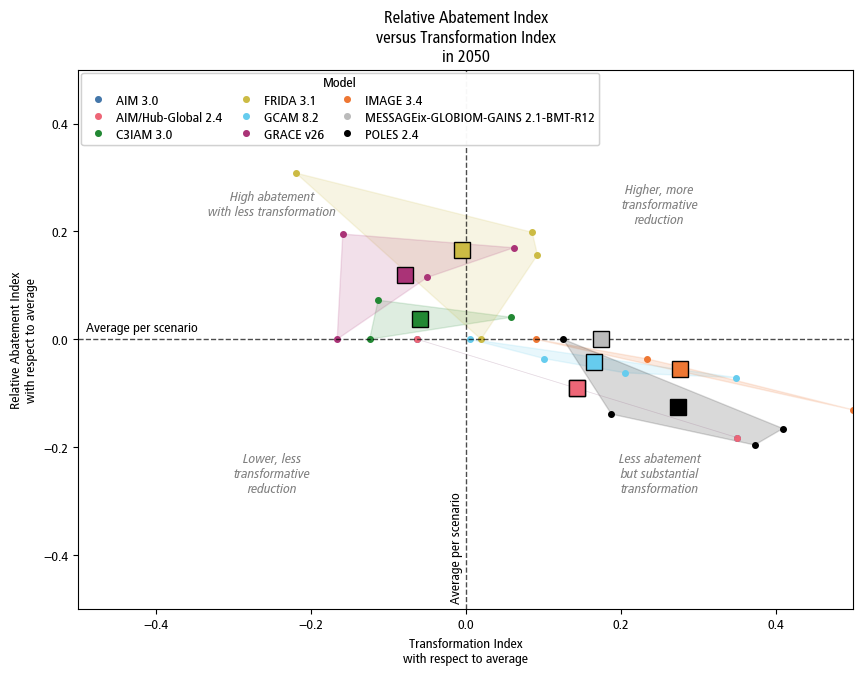

In [47]:
INDx = 'Transformation Index'
INDy = 'Relative Abatement Index'
fig, ax = plt.subplots(figsize=(10, 7))

for mod_i, mod in enumerate(ds.model):
    color = colors[mod_i]

    points = []

    short_name = f"{str(mod.values)[:]}"# {str(mod.values).split()[-1]}"

    for SCEN_i, SCEN in enumerate(['C400-lin', 'C80-gr5', 'C160-gr5', 'Current-Policies']):

        median_x = ds_ex.sel(scenario=SCEN, region='World', year=2050)[INDx].mean(dim='model')
        median_y = ds_ex.sel(scenario=SCEN, region='World', year=2050)[INDy].mean(dim='model')

        x = float(ds.sel(model=mod, scenario=SCEN, region='World', year=2050)[INDx] - median_x)
        y = float(ds.sel(model=mod, scenario=SCEN, region='World', year=2050)[INDy] - median_y)

        points.append((x, y))

        ax.plot(
            x, y,
            '.',
            color=color,
            markersize=8,
            label=short_name if SCEN_i == 0 else None
        )

    points = np.array(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]

    # Plot average
    if len(points) > 0:
        avg = points.mean(axis=0)
        ax.plot(avg[0], avg[1],
                marker='s', markersize=12,
                color=color, markeredgecolor='k', zorder=5)
    if len(points) == 2:
        ax.plot(points[:,0],points[:,1],
                color=color, lw=0.5, alpha=0.15, zorder=4)
    # Only draw if at least 3 valid points remain
    if len(points) >= 3:
        centroid = points.mean(axis=0)
        angles = np.arctan2(points[:,1] - centroid[1],
                            points[:,0] - centroid[0])
        points = points[np.argsort(angles)]

        ax.add_patch(Polygon(points,
                            closed=True,
                            facecolor=color,
                            edgecolor=color,
                            alpha=0.15))

# Legend
legend1 = ax.legend(
    title="Model",
    loc="upper left",
    ncol=3,
    fontsize=10,
    title_fontsize=10,
    columnspacing=0.8,
    handletextpad=0.4,
    labelspacing=0.3,
    handlelength=1.8,
    borderpad=0.3,
    borderaxespad=0.2,
)
ax.add_artist(legend1)

# Add horizontal line at 0
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.text(-0.49, 0.01, 'Average per scenario', color='black', fontsize=10, va='bottom', ha='left')
ax.text(-0.02, -0.49, 'Average per scenario', color='black', rotation=90, fontsize=10, va='bottom', ha='left')
ax.text(-0.25, -0.25, 'Lower, less\ntransformative\nreduction', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(0.25, 0.25, 'Higher, more\ntransformative\nreduction', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(-0.25, 0.25, 'High abatement\nwith less transformation', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')
ax.text(0.25, -0.25, 'Less abatement\nbut substantial\ntransformation', color='grey', fontsize=10, va='center', ha='center', fontstyle='italic')

ax.set_title(f"{INDy}\nversus {INDx}\nin 2050")
ax.set_ylabel(f"{INDy}\nwith respect to average")
ax.set_xlabel(f"{INDx}\nwith respect to average")
ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-0.5, 0.5])
plt.savefig(paths.figures_Xdrive / "rai_ti.png", dpi=500, bbox_inches='tight')